In [161]:
def get_twiss(lattice, variables,path):
    twiss_code = f"""
        include '{lattice}_maps';
    
    PROCEDURE PICK INDEX MAPARR SPNRARR;
      VARIABLE I 1; VARIABLE J 1;
      LOOP I 1 TWOND;
        MSC(I) := MAPARR(I, INDEX);
      ENDLOOP;
      LOOP I 1 3;
        LOOP J 1 3;
          SSCR(I,J) := SPNRARR(I,J,INDEX) + 0*DD(1);
        ENDLOOP;
      ENDLOOP;
    ENDPROCEDURE;
    
    PROCEDURE MAKEMAP FROM TO START MAPARR SPNRARR; 
      VARIABLE J 1;
      WRITE 6 '* '&ST(START);
      LMAPS START MAPARR SPNRARR;
      LOOP J (START+1) TO;
        WRITE 6 '**       '&ST(J);
        PICK J MAPARR SPNRARR;
        LOCSET 0 0 0 0 0 0;
        UPDATE 1 1;
      ENDLOOP;
      LOOP J FROM (START-1);
        WRITE 6 '**       '&ST(J);
        PICK J MAPARR SPNRARR;
        LOCSET 0 0 0 0 0 0;
        UPDATE 1 1;
      ENDLOOP;
    ENDPROCEDURE;
    
    PROCEDURE GETTWISS0 COORD AL0 BET0 GAM0 MAPARR SPNRARR;
      VARIABLE NUM1 1;
      VARIABLE NUM2 1;
      VARIABLE OBJ 1;
      IF COORD='X'; NUM1:=1;NUM2:=2;      AL0:=0; BET0:=20.0; GAM0:=1.0/BET0;
      ELSEIF COORD='Y'; NUM1:=3;NUM2:=4;  AL0:=0; BET0:=3;    GAM0:=1.0/BET0;
      ELSEIF LO(1); WRITE 6 'UNKNOWN COORDINATE';
      ENDIF;
      FIT AL0 BET0 GAM0;
        OBJ:= SQR(SQR(ME(NUM1,NUM1))*BET0-2*ME(NUM1,NUM1)*ME(NUM1,NUM2)*AL0+SQR(ME(NUM1,NUM2))*GAM0-BET0);
        OBJ:=OBJ+ SQR(-ME(NUM1,NUM1)*ME(NUM2,NUM1)*BET0+( ME(NUM1,NUM1)*ME(NUM2,NUM2)+ME(NUM1,NUM2)*ME(NUM2,NUM1) )*AL0-ME(NUM1,NUM2)*ME(NUM2,NUM2)*GAM0-AL0);
        OBJ:=OBJ+ SQR((ME(NUM2,NUM1)^2)*BET0-2*ME(NUM2,NUM1)*ME(NUM2,NUM2)*AL0+(ME(NUM2,NUM2)^2)*GAM0-(1+AL0^2)/BET0)  ;
      ENDFIT 1E-20 5000 1 OBJ;
      WRITE 6 'AL'&COORD&'0' 'BET'&COORD&'0' 'GAM'&COORD&'0';
      WRITE 6 AL0 BET0 GAM0;
    ENDPROCEDURE;
    
    PROCEDURE BETS TAG COORD NUM_ELE AL0 BET0 GAM0 BETS MAPARR SPNRARR;
      VARIABLE J 1;
      VARIABLE NUM1 1;
      VARIABLE NUM2 1;
      VARIABLE MRKR 100;
      IF COORD='X'; NUM1:=1;NUM2:=2;
      ELSEIF COORD='Y'; NUM1:=3;NUM2:=4;
      ELSEIF LO(1); WRITE 6 'UNKNOWN COORDINATE';
      ENDIF;
      UM;BETS(1):=BET0;
      OPENF 800 '{path}{lattice}_'&TAG&'.dat' 'REPLACE';
    write 800 '#beta'&COORD&' 			 N_ele';
      WRITE 800 ST(BETS(1))&'     '&ST(0);
      LOOP J 1 NUM_ELE;
        MAKEMAP 1 J 1 MAPARR SPNRARR;
        BETS(J+1):=(ME(NUM1,NUM1)^2)*BET0-2*ME(NUM1,NUM1)*ME(NUM1,NUM2)*AL0+(ME(NUM1,NUM2)^2)*GAM0;
        WRITE 800 ST(BETS(J+1))&'     '&ST(J);
        UM;
      ENDLOOP;
      CLOSEF 800;
    ENDPROCEDURE;
    
    PROCEDURE GETDISP0 COORD D0 DPR0 MAPARR SPNRARR;
      VARIABLE NUM1 1;
      VARIABLE NUM2 1;
      VARIABLE OBJ 1;
      IF COORD='X'; NUM1:=1;NUM2:=2;      D0:=0; DPR0:=0;
      ELSEIF COORD='Y'; NUM1:=3;NUM2:=4;  D0:=0; DPR0:=0;
      ELSEIF LO(1); WRITE 6 'UNKNOWN COORDINATE';
      ENDIF;
      FIT D0 DPR0;
        OBJ:= SQR(  ME(NUM1,NUM1)*D0+ME(NUM1,NUM2)*DPR0+ME(NUM1,6)*(1+1/(CONS(ETA)+1))-D0  );
        OBJ:=OBJ+ SQR(  ME(NUM2,NUM1)*D0+ME(NUM2,NUM2)*DPR0+ME(NUM2,6)*(1+1/(CONS(ETA)+1))-DPR0  )  ;
      ENDFIT 1E-20 5000 1 OBJ;
      WRITE 6 'DISP'&COORD&'0' 'DISP_PRIME'&COORD&'0';
      WRITE 6 D0 DPR0;
    ENDPROCEDURE;
    
    PROCEDURE DISPS TAG COORD NUM_ELE D0 DPR0 DS MAPARR SPNRARR;
      VARIABLE J 1;
      VARIABLE NUM1 1;
      VARIABLE MRKR 100;
      VARIABLE NUM2 1;
      IF COORD='X'; NUM1:=1;NUM2:=2;
      ELSEIF COORD='Y'; NUM1:=3;NUM2:=4;
      ELSEIF LO(1); WRITE 6 'UNKNOWN COORDINATE';
      ENDIF;
      UM;
      DS(1):=D0;
      OPENF 800 '{path}{lattice}_'&TAG&'.dat' 'REPLACE';
      write 800 '#disps'&COORD&' 			 N_ele';
      WRITE 800 ST(DS(1))&'     '&ST(0);
      LOOP J 1 NUM_ELE;
        MAKEMAP 1 J 1 MAPARR SPNRARR;
        DS(J+1):=ME(NUM1,NUM1)*D0+ME(NUM1,NUM2)*DPR0+ ME(NUM1,6)*(1+1/(CONS(ETA)+1));
        WRITE 800 ST(DS(J+1))&'     '&ST(J);
      UM;ENDLOOP;
      CLOSEF 800;
    ENDPROCEDURE;
    
    PROCEDURE MAIN;
      VARIABLE GAMMA 1;
      VARIABLE SGx1 1; VARIABLE SGx2 1; VARIABLE SGy1 1; VARIABLE SGy2 1; VARIABLE EB1 1;
    
      VARIABLE ALPHAX0 1; VARIABLE BETAX0 1; VARIABLE GAMMAX0 1;
      VARIABLE BETAXS 1 666;
      VARIABLE ALPHAY0 1; VARIABLE BETAY0 1; VARIABLE GAMMAY0 1;
      VARIABLE BETAYS 1 666;
      VARIABLE DISPX0 1; VARIABLE DISPXPR0 1;
      VARIABLE DISPXS 1 666;
      VARIABLE DISPY0 1; VARIABLE DISPYPR0 1;
      VARIABLE DISPYS 1 666;
      VARIABLE MAPARR1 1000 6 666; VARIABLE SPNRARR1 1000 3 3 666;
      VARIABLE NUM_ELE 1;
      VARIABLE TILT 48;
      
    GAMMA :=  {variables[1]};
    NUM_ELE := {variables[0]};
    
      TILT := ZEROS(48);
      OV 3 3 0;
     SET_FOR_{variables[2]} GAMMA;
    
      SGx1 :=  0.0;
      SGy1  := 0.0;
      SGx2 :=  0.0;
      SGy2  := 0.0;
    
    EB1 := {variables[3]};
    
    DISPX0:= 0;
    BETAX0:= {variables[4]};
      BETAY0:={variables[5]};
      ALPHAX0:=0.0;
      ALPHAY0:=0.0;
    
      GAMMAX0:=(1+SQR(ALPHAX0))/BETAX0;
      GAMMAY0:=(1+SQR(ALPHAY0))/BETAY0;
    
    LATTICE SGx1 SGy1 SGx2 SGy1 EB1 0 MAPARR1 SPNRARR1; PM 6;
    
      WRITE 6 '++++++++++ Magnetic Rigidity';
      WRITE 6 CONS(CHIM);
      WRITE 6 ME(3,6);

        BETS 'BETAX' 'X' NUM_ELE ALPHAX0 BETAX0 GAMMAX0 BETAXS MAPARR1 SPNRARR1;
         BETS 'BETAY' 'Y' NUM_ELE ALPHAY0 BETAY0 GAMMAY0 BETAYS MAPARR1 SPNRARR1;
         DISPS 'DISPX' 'X' NUM_ELE DISPX0 DISPXPR0 DISPXS MAPARR1 SPNRARR1;
        
        
          ENDPROCEDURE; 
        
        PROCEDURE RUN;
          MAIN;
        ENDPROCEDURE;
        RUN; END;
        
            """
    with open(f"twiss_{lattice}.fox", "w") as f:
        f.write(twiss_code)
    name = f"twiss_{lattice}"
    return(name)
        

In [164]:
import subprocess
import os

def variables(lattice, gamma, particle, field, path, const): 
    filename = f"{path}{lattice}{const}"
    names = ["N", "NAME", "S[cm]", "BetaX[cm]", "AlfaX", "BetaY[cm]", "AlfaY", "DspX[cm]", "DspXp", "DspY[cm]", "DspYp", "NuX", "NuY"]
    df = pd.read_csv(filename, comment="#", delim_whitespace=True, header=None, names=names)
    df = df.sort_values("N")
    NUM_ELE = len(df) - 2
    BETAX = df["BetaX[cm]"].values
    BETAY = df["BetaY[cm]"].values
    dispx = df["DspX[cm]"].values
    BETAX0 = BETAX[0]/100
    BETAY0 = BETAY[0]/100
    DISPX0 = dispx[0]/100
    variables = [NUM_ELE, gamma, particle, field, BETAX0, BETAY0, DISPX0]
    return(variables)
    
def twiss(lattice, gamma, particle, field, path, const, fileid):
    var = variables(lattice, gamma, particle, field, path, const)
    c = get_twiss(lattice, var,path)
    subprocess.Popen(f'start cmd /c cosy {c}.fox', shell=True)
    
# print lattice name, energy, particle, field value
#"magnetic_2p", 1.143914, "deuterons", 0
#"electrostatic", 1.24810736, "protons", 112.46439

path = "C:/Users/palo4/Desktop/MEPHI/Master/HNP/MIPT conf/COSY/twiss/" 
#default names:
optimx_filename_id = "_twiss_optimX.dat"
fileid = ["_DISPX.dat", "_BETAX.dat", "_BETAY.dat"]

twiss("magnetic_2p", 1.143914, "deuterons", 0, path, optimx_filename_id, fileid)

C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\1322414064.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, comment="#", delim_whitespace=True, header=None, names=names)


C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'd

<Figure size 1200x900 with 0 Axes>

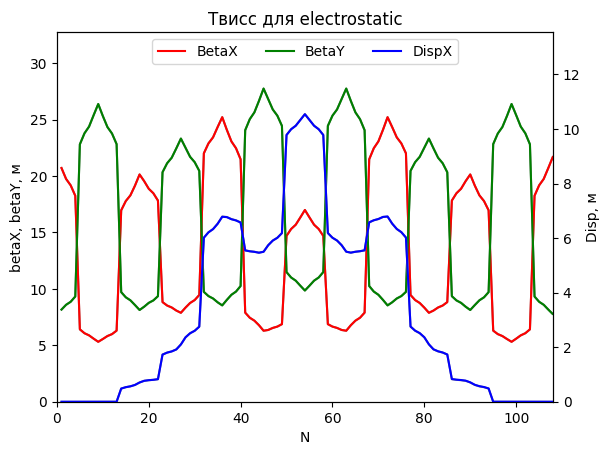

C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)
C:\Users\palo4\AppData\Local\Temp\ipykernel_17616\526082710.py:20: FutureWarning: The 'd

<Figure size 1200x900 with 0 Axes>

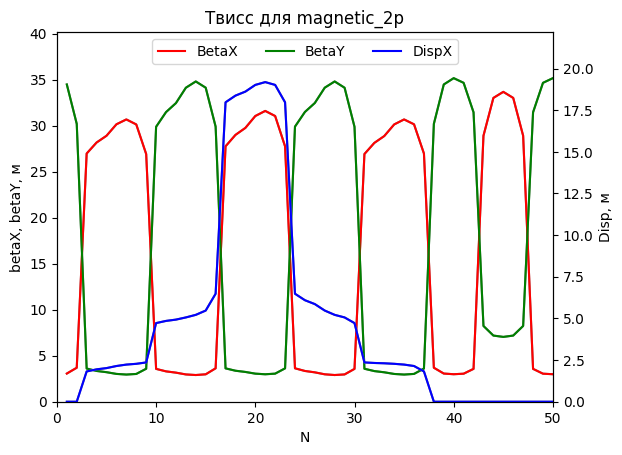

In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plottwiss(lattice, period_number, path, const, fileid):
    filenames = [f"{path}{lattice}{const}", f"{path}{lattice}{fileid[0]}", f"{path}{lattice}{fileid[1]}", f"{path}{lattice}{fileid[2]}"]
    data = []
    for i in range(len(filenames)):
        if i == 0:
            names = ["Num", "NAME", "S[cm]", "BetaX[cm]", "AlfaX", "BetaY[cm]", "AlfaY", "DspX[cm]", "DspXp", "DspY[cm]", "DspYp", "NuX", "NuY"]
        elif i == 1:
            names = ["dispsX", "N"]
        elif i == 2:
            names = ["betax", "N"]
        else:
            names = ["betay", "N"]
            
            # читаем файл
        df = pd.read_csv(filenames[i], comment="#", delim_whitespace=True, header=None, names=names)

        if "N" in df.columns:
            df = df.sort_values("N")
        elif "Num" in df.columns:
            df = df.sort_values("Num")
        if i == 0:
            N = df["Num"].values[1:-1]
            D = df["DspX[cm]"].values[1:-1]
            X = df["BetaX[cm]"].values[1:-1]
            Y = df["BetaY[cm]"].values[1:-1]
            data.append((N, D, X, Y))
        if i ==1:
            dispx = df["dispsX"].values[1:]
            data.append(dispx)
        if i==2:
            betax = df["betax"].values[1:]
            data.append(betax)
        if i ==3:
            betay = df["betay"].values[1:]
            data.append(betay)

    N = np.arange(0, len(data[0][0]))
    plt.figure(figsize=(12, 9))

    fig, ax1 = plt.subplots()

    ax1.set_ylabel("betaX, betaY, м")
    ax1.set_xlabel("N")
    ax1.plot(data[0][0][N], data[0][2][N]/100, color='grey')
    ax1.plot(data[0][0][N], data[0][3][N]/100, color='grey')
    line1, = ax1.plot(data[0][0][N], data[2][N], color='red', label="BetaX")
    line2, = ax1.plot(data[0][0][N], data[3][N], color='green', label="BetaY")
    ax1.set_ylim(0, (np.max(np.concatenate((data[2], data[3], data[0][2]/100, data[0][3]/100)))+5))
    ax1.set_title(f"Твисс для {lattice}")  # ← вот здесь
    ax1.set_xlim(0, len(data[0][0])//period_number)
    
    ax2 = ax1.twinx()  # ← вторая шкала справа
    ax2.plot(N, Y)
    ax2.plot(data[0][0][N], data[0][1][N]/100, color='grey')
    line3, = ax2.plot(data[0][0][N], data[1][N], color='blue', label="DispX")
    ax2.set_ylabel("Disp, м")
    ax2.set_ylim(0, (np.max(np.concatenate((data[1][N], data[0][1][N]/100)))+3))

    ax1.legend(handles=[line1, line2, line3], loc="upper center", ncol=3)
    
    plt.show()

periodicity1 = 5
periodicity2 = 2
plottwiss("electrostatic", periodicity1, path, optimx_filename_id, fileid)
plottwiss("magnetic_2p", periodicity2, path, optimx_filename_id, fileid)